#### ロトカ-ヴォルテラ方程式

\begin{align*}
    \dot{x} = \alpha x - \beta xy  \\
    \dot{y} = \delta xy - \gamma y
\end{align*}  

$x$ は被食者、$y$ は捕食者の個体数。  

- $\alpha$：被食者の自然成長率
    - 捕食者が存在しない場合、$$\dot{x} = \alpha x$$
- $\beta$：捕食率
    - 捕食が被食者をどれだけ減らすか
- $\gamma$：捕食者の死亡率
    - 被食者が存在しない場合、$$\dot{y} = -\gamma y$$
- $\delta$：捕食効率
    - 捕食によって得られた被食者が、どれだけ捕食者の増殖に結びつくか



##### 安定性を調べる
1. 定常点
$$x^* = \frac{\gamma}{\delta},$$ $$y^* = \frac{\alpha}{\beta}$$  
または、$$x^* = 0,$$ $$y^* = 0$$  
2. ヤコビアン  
右辺を $f(x,y) = \alpha x - \beta xy$, $g(x,y) = \delta xy - \gamma y$ とすると、$$J(x,y) = \begin{pmatrix} \frac{\partial{f}}{\partial{x}} & \frac{\partial{f}}{\partial{y}} \\ \frac{\partial{g}}{\partial{x}} & \frac{\partial{g}}{\partial{y}} \end{pmatrix} = \begin{pmatrix} \alpha - \beta y & -\beta x \\ \delta y & \delta x - \gamma \end{pmatrix}. $$  
3. 各定常点で固有値を計算  
    - $(0,0)$ の安定性 $$J(0,0) = \begin{pmatrix} \alpha & 0 \\ 0 & -\gamma \end{pmatrix}. $$  
    固有値は、$$\lambda_1 = \alpha > 0, $$ $$\lambda_2 = \gamma < 0.$$  
    符号が正と負に分かれているのでこの定常点は鞍点。したがって、ある方向では軌道は原点に近づくが、別の方向では指数的に離れるため不安定。  
    ※マクロ経済学でよく用いられるラムゼイモデルなどの動学モデルでは、鞍点の場合には解が収束するがこれは横断性条件や非Ponziゲームにより発散解が禁止されているからである。  
    
    - $(\frac{\gamma}{\delta},\frac{\alpha}{\beta})$ の安定性 $$J(x^*,y^*) = \begin{pmatrix} 0 & \beta x^* \\ \delta y^* & 0 \end{pmatrix} = \begin{pmatrix} 0 & -\beta\frac{\gamma}{\delta} \\ \delta\frac{\alpha}{\beta} & 0 \end{pmatrix} . $$  
    固有値は、$$\lambda^2 = det(J) = -\alpha \gamma$$  
    より、$$\lambda_{1,2} = \plusmn i\sqrt{\alpha \gamma}$$  
    固有値が純虚数で実部が0のため、定常点の周囲を回転するという挙動をとる。このため、この内部定常点は中立安定。


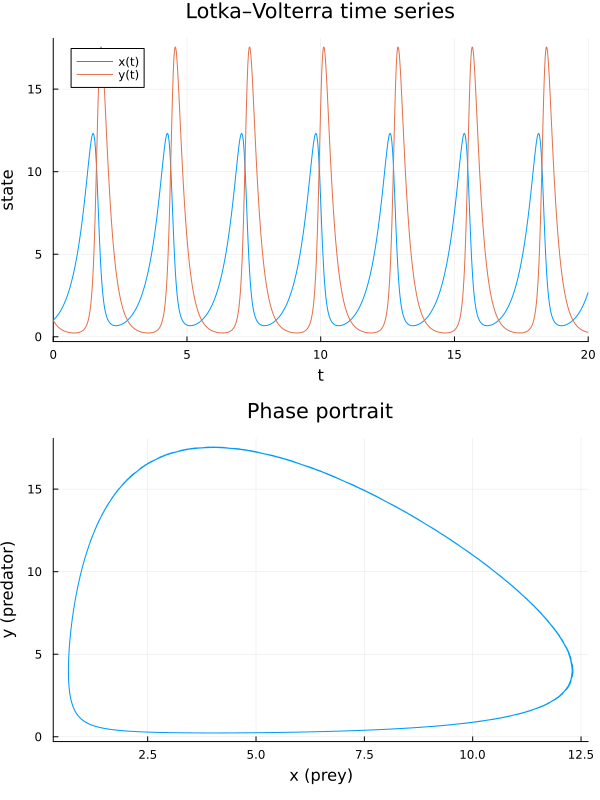

In [14]:
using DifferentialEquations
using Plots

# ロトカ–ヴォルテラの右辺
function lotka_volterra!(du, u, p, t)
    x, y = u
    α, β, δ, γ = p
    du[1] = α*x - β*x*y
    du[2] = δ*x*y - γ*y
end

# パラメータと初期値
p  = (2.0, 0.5, 1.0, 4.0)   # (α, β, δ, γ)
u0 = [1.0, 1.0]            # (x(0), y(0))
tspan = (0.0, 20.0)

prob = ODEProblem(lotka_volterra!, u0, tspan, p)
sol = solve(prob; reltol=1e-9, abstol=1e-9)

# 1) 時系列
p1 = plot(sol, xlabel="t", ylabel="state", title="Lotka–Volterra time series", label=["x(t)" "y(t)"])

# 2) 位相図（x–y 平面）
x = sol[1, :]
y = sol[2, :]
p2 = plot(x, y, xlabel="x (prey)", ylabel="y (predator)", title="Phase portrait", legend=false)

plot(p1, p2, layout=(2,1), size=(600,800))


#### 非線形に拡張したロトカ-ヴォルテラ方程式

$$\dot{x} = x(\alpha - ax - \beta y),$$ $$\dot{y} = y(-\gamma + \delta x - by)$$  
$a$：被食者の自己抑制、$b$：捕食者の自己抑制と2次の項が追加された。

Coexistence steady state: x* = 1.28, y* = 0.5599999999999999
max ΔV (should be <= 0 up to numerical noise): 2.9753835647534817e-16


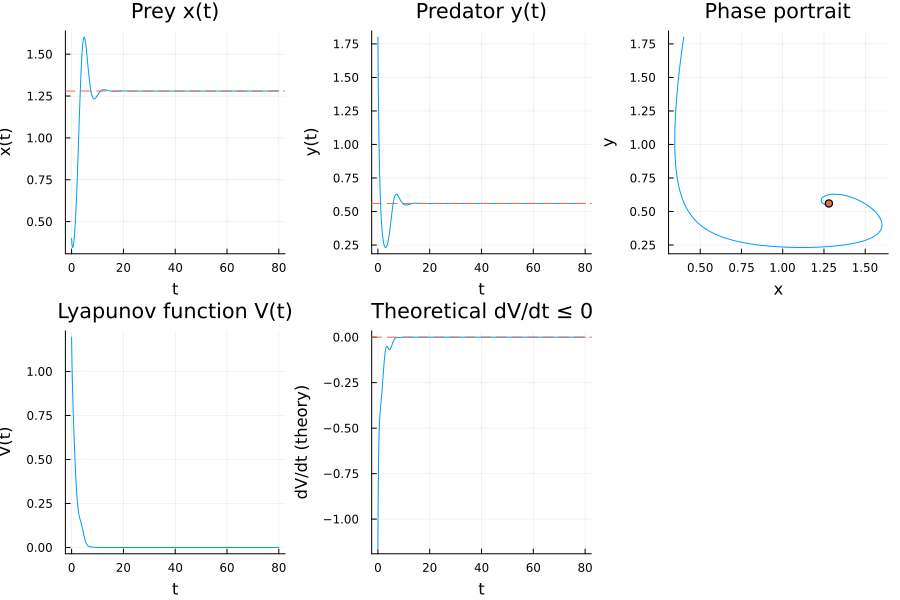

In [22]:
using DifferentialEquations
using DiffEqCallbacks
using Plots

# -----------------------------
# 1) パラメータ（すべて正）
#    共存条件: α*δ > a*γ を満たすように選ぶ
# -----------------------------
α = 1.2     # prey intrinsic growth
a = 0.5     # prey self-limitation
β = 1.0     # predation intensity
γ = 1.0     # predator natural death
δ = 1.0     # conversion efficiency
b = 0.5     # predator self-limitation

@assert α*δ > a*γ "共存条件 α*δ > a*γ を満たしていません（y*が正になりません）。"

# -----------------------------
# 2) 共存定常点 (x*, y*)
#    x*=(βγ + bα)/(βδ + ab), y*=(αδ - aγ)/(βδ + ab)
# -----------------------------
den = β*δ + a*b
x_star = (β*γ + b*α) / den
y_star = (α*δ - a*γ) / den

println("Coexistence steady state: x* = $(x_star), y* = $(y_star)")

# -----------------------------
# 3) ODE（非線形拡張LV）
# -----------------------------
function glv_selflim!(du, u, p, t)
    x, y = u
    α, a, β, γ, δ, b = p

    du[1] = x * (α - a*x - β*y)
    du[2] = y * (-γ + δ*x - b*y)
end

p = (α, a, β, γ, δ, b)

# 正の領域を保つ（数値誤差で負に落ちるのを防ぐ）
cb = PositiveDomain()

# -----------------------------
# 4) リャプノフ関数 V(x,y)
#    V >= 0, dV/dt = -δ a (x-x*)^2 - β b (y-y*)^2 <= 0
# -----------------------------
function lyapunov_V(x, y; x_star=x_star, y_star=y_star, β=β, δ=δ)
    # x,y>0 を前提（PositiveDomainで担保）
    termx = x - x_star - x_star*log(x / x_star)
    termy = y - y_star - y_star*log(y / y_star)
    return δ*termx + β*termy
end

# 理論上の dV/dt（検算用；数値微分ではなく解析式を使う）
function lyapunov_dV(x, y; x_star=x_star, y_star=y_star, β=β, δ=δ, a=a, b=b)
    return -δ*a*(x - x_star)^2 - β*b*(y - y_star)^2
end

# -----------------------------
# 5) シミュレーション設定
# -----------------------------
u0 = [0.4, 1.8]          # 初期値（x0>0, y0>0）
tspan = (0.0, 80.0)

prob = ODEProblem(glv_selflim!, u0, tspan, p)
sol  = solve(prob, Tsit5(); callback=cb, reltol=1e-9, abstol=1e-9, saveat=0.05)

t = sol.t
x = sol[1, :]
y = sol[2, :]

V  = [lyapunov_V(xi, yi) for (xi, yi) in zip(x, y)]
dV = [lyapunov_dV(xi, yi) for (xi, yi) in zip(x, y)]

# 単調性の簡易チェック（増えている箇所がないか）
max_increase = maximum(diff(V))
println("max ΔV (should be <= 0 up to numerical noise): ", max_increase)

# -----------------------------
# 6) プロット
# -----------------------------
p1 = plot(t, x, xlabel="t", ylabel="x(t)", title="Prey x(t)", legend=false)
hline!(p1, [x_star], linestyle=:dash)

p2 = plot(t, y, xlabel="t", ylabel="y(t)", title="Predator y(t)", legend=false)
hline!(p2, [y_star], linestyle=:dash)

p3 = plot(x, y, xlabel="x", ylabel="y", title="Phase portrait", legend=false)
scatter!(p3, [x_star], [y_star], ms=4)

p4 = plot(t, V, xlabel="t", ylabel="V(t)", title="Lyapunov function V(t)", legend=false)

p5 = plot(t, dV, xlabel="t", ylabel="dV/dt (theory)", title="Theoretical dV/dt ≤ 0", legend=false)
hline!(p5, [0.0], linestyle=:dash)

plot(p1, p2, p3, p4, p5, layout=(2,3), size=(900,600))
